# Konfidenzellipse und Wilson-Intervall

Für jeden Parameterwert $p$ wird ein normalapproximatives Prognoseintervall für die relative Häufigkeit $H_n$ eingezeichnet. Die Gesamtheit dieser Intervalle bildet das Prognoseband im $(p,h)$-Raum; seine beiden Randkurven bilden eine Ellipse.

Eine beobachtete Realisation $h_0=k/n$ schneidet das Band. Die zugehörigen Parameterwerte bilden das zu $h_0$ gehörende Wilson-Konfidenzintervall.

## Eingaben

Nur die folgende Zelle muss verändert werden. Die Klasse `Config` bündelt vier Arten von Eingaben:

- mathematische Eingaben,
- Elemente der Grafik,
- Beschriftung,
- Anzeige und Speicherung.

Die Beobachtung wird bewusst durch die ganzzahlige Trefferzahl $k$ eingegeben. Die relative Häufigkeit $h_0=k/n$ wird daraus berechnet. So kann nur ein Wert entstehen, der bei einer Binomialstichprobe tatsächlich möglich ist. Beispielsweise wäre bei $n=80$ die freie Eingabe $h_0=0{,}64$ unzulässig, denn $80\cdot0{,}64=51{,}2$ ist keine ganze Trefferzahl.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


@dataclass(frozen=True)
class Config:
    # Mathematische Eingaben
    n: int = 80
    k: int = 52
    gamma: float = 0.95

    # Elemente der Grafik
    show_vertical_intervals: bool = True
    number_of_vertical_intervals: int = 18
    show_projection: bool = True
    show_diagonal: bool = True
    show_band_fill: bool = True

    # Beschriftung der Grafik
    show_title: bool = True
    show_subtitle: bool = True
    show_result_line: bool = True

    # Ausgabe des Notebooks
    show_text_output: bool = True
    show_figure: bool = True
    save_figure: bool = True
    save_formats: tuple[str, ...] = ("png", "pdf")
    output_dir: str = "fig"
    png_dpi: int = 240


cfg = Config()

## Prüfung und mathematische Berechnung

Zunächst werden die Eingaben geprüft. Danach folgen voneinander getrennte Funktionen für das Prognoseband und das Wilson-Intervall. Alle benötigten Größen werden als Argumente übergeben; die mathematischen Funktionen greifen nicht auf globale Zwischenwerte zu.

Die Randkurven des Prognosebandes sind

$$
h=p\pm z\sqrt{\frac{p(1-p)}{n}}.
$$

Ihre Inversion für die beobachtete Realisation $h_0=k/n$ liefert die Grenzen des Wilson-Intervalls.

In [2]:
@dataclass(frozen=True)
class Calculation:
    h0: float
    z: float
    p: np.ndarray
    lower: np.ndarray
    upper: np.ndarray
    p_left: float
    p_right: float


def validate_config(cfg: Config) -> None:
    if not isinstance(cfg.n, int) or isinstance(cfg.n, bool) or cfg.n <= 0:
        raise ValueError("n muss eine positive ganze Zahl sein.")
    if not isinstance(cfg.k, int) or isinstance(cfg.k, bool):
        raise ValueError("k muss eine ganze Zahl sein.")
    if not 0 <= cfg.k <= cfg.n:
        raise ValueError("k muss zwischen 0 und n liegen.")
    if not 0.0 < cfg.gamma < 1.0:
        raise ValueError("gamma muss zwischen 0 und 1 liegen.")
    if cfg.number_of_vertical_intervals < 2:
        raise ValueError("number_of_vertical_intervals muss mindestens 2 sein.")
    if cfg.png_dpi <= 0:
        raise ValueError("png_dpi muss positiv sein.")
    if not cfg.output_dir.strip():
        raise ValueError("output_dir darf nicht leer sein.")

    formats = {fmt.lower().lstrip(".") for fmt in cfg.save_formats}
    unsupported = formats - {"png", "pdf"}
    if unsupported:
        names = ", ".join(sorted(unsupported))
        raise ValueError(f"Nicht unterstützte Speicherformate: {names}")


def prediction_bounds(
    p: np.ndarray,
    *,
    n: int,
    z: float,
) -> tuple[np.ndarray, np.ndarray]:
    half_width = z * np.sqrt(p * (1.0 - p) / n)
    return p - half_width, p + half_width


def wilson_interval(
    *,
    n: int,
    k: int,
    z: float,
) -> tuple[float, float]:
    h0 = k / n
    denominator = 1.0 + z**2 / n
    center = (h0 + z**2 / (2.0 * n)) / denominator
    half_width = (
        z
        * math.sqrt(h0 * (1.0 - h0) / n + z**2 / (4.0 * n**2))
        / denominator
    )
    return center - half_width, center + half_width


def calculate(cfg: Config) -> Calculation:
    validate_config(cfg)

    h0 = cfg.k / cfg.n
    z = norm.ppf((1.0 + cfg.gamma) / 2.0)
    p = np.linspace(0.0, 1.0, 2001)
    lower, upper = prediction_bounds(p, n=cfg.n, z=z)
    p_left, p_right = wilson_interval(n=cfg.n, k=cfg.k, z=z)

    return Calculation(
        h0=h0,
        z=z,
        p=p,
        lower=lower,
        upper=upper,
        p_left=p_left,
        p_right=p_right,
    )

## Grafik

Die Funktion `create_figure()` erzeugt ausschließlich die Grafik. Welche Elemente sichtbar sind, wird in `Config` festgelegt. Titel, Untertitel und Ergebniszeile können unabhängig voneinander ein- und ausgeblendet werden.

Der Untertitel enthält nur die Eingaben $n$, $k$ und $\gamma$. Die daraus berechneten Größen $h_0=k/n$ und das Wilson-Konfidenzintervall stehen in einer eigenen Ergebniszeile unterhalb der $p$-Achse -- außerhalb des Koordinatensystems.

In [3]:
def create_figure(
    cfg: Config,
    calculation: Calculation,
) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(figsize=(7.2, 7.2))

    lower_clipped = np.clip(calculation.lower, 0.0, 1.0)
    upper_clipped = np.clip(calculation.upper, 0.0, 1.0)

    if cfg.show_band_fill:
        ax.fill_between(
            calculation.p,
            lower_clipped,
            upper_clipped,
            color="tab:blue",
            alpha=0.16,
        )

    ax.plot(
        calculation.p,
        calculation.lower,
        linewidth=2.2,
        color="tab:blue",
    )
    ax.plot(
        calculation.p,
        calculation.upper,
        linewidth=2.2,
        color="tab:blue",
    )

    if cfg.show_diagonal:
        ax.plot(
            calculation.p,
            calculation.p,
            linestyle="--",
            linewidth=0.8,
            color="gray",
        )

    if cfg.show_vertical_intervals:
        selected_p = np.linspace(
            calculation.p_left,
            calculation.p_right,
            cfg.number_of_vertical_intervals,
        )
        selected_lower, selected_upper = prediction_bounds(
            selected_p,
            n=cfg.n,
            z=calculation.z,
        )
        ax.vlines(
            selected_p,
            np.clip(selected_lower, 0.0, 1.0),
            np.clip(selected_upper, 0.0, 1.0),
            linewidth=1.5,
            color="tab:blue",
            zorder=3,
        )

    ax.axhline(
        calculation.h0,
        linewidth=1.8,
        color="gray",
    )
    ax.scatter(
        [calculation.p_left, calculation.p_right],
        [calculation.h0, calculation.h0],
        s=25,
        color="gray",
        zorder=6,
    )

    if cfg.show_projection:
        ax.vlines(
            [calculation.p_left, calculation.p_right],
            ymin=0.0,
            ymax=calculation.h0,
            linestyles=":",
            linewidth=1.2,
            color="gray",
        )
        ax.plot(
            [calculation.p_left, calculation.p_right],
            [0.0, 0.0],
            linewidth=6.0,
            solid_capstyle="butt",
            clip_on=False,
            color="tab:green",
            zorder=7,
        )

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$p$", fontsize=17)
    ax.set_ylabel(r"$h$", fontsize=17, rotation=0, labelpad=14)
    ax.tick_params(labelsize=12)

    title = "Konfidenzellipse und Wilson-Intervall"
    subtitle = (
        rf"$n={cfg.n},\quad k={cfg.k},\quad "
        rf"\gamma={cfg.gamma:.2f}$"
    )
    confidence = f"{100.0 * cfg.gamma:g}"
    result_line = (
        rf"$h_0=k/n={cfg.k}/{cfg.n}={calculation.h0:.3f}$"
        rf"$\qquad {confidence}\,\%$-Wilson-KI: "
        rf"$[{calculation.p_left:.4f};\,{calculation.p_right:.4f}]$"
    )

    if cfg.show_title and cfg.show_subtitle:
        ax.set_title(title, fontsize=16, pad=32)
        ax.text(
            0.5,
            1.015,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=11,
            color="0.15",
        )
    elif cfg.show_title:
        ax.set_title(title, fontsize=16, pad=14)
    elif cfg.show_subtitle:
        ax.set_title(subtitle, fontsize=11, color="0.15", pad=14)

    if cfg.show_result_line:
        fig.text(
            0.52,
            0.04,
            result_line,
            ha="center",
            va="bottom",
            fontsize=10.5,
            color="0.15",
        )
        fig.tight_layout(rect=(0.0, 0.065, 1.0, 1.0))
    else:
        fig.tight_layout()

    return fig, ax

## Ausgabe

Berechnung, Erzeugung der Grafik sowie Anzeige und Speicherung bleiben getrennt. Die Grafik kann unabhängig voneinander angezeigt und gespeichert werden.

Ist `save_figure = True`, wird der relative Unterordner `fig/` bei Bedarf automatisch angelegt. PNG- und PDF-Dateien werden dort gesammelt; das Verzeichnis des Notebooks bleibt frei von einzelnen Grafikdateien.

Der Dateiname wird automatisch aus den mathematischen Eingaben gebildet. Für die Standardeinstellungen entstehen

- `Wilson-Konfidenzellipse-n80-k52-gamma095.png`,
- `Wilson-Konfidenzellipse-n80-k52-gamma095.pdf`.

h_0 = k/n = 52/80 = 0.6500
95 %-Wilson-Konfidenzintervall: [0.5408; 0.7455]
Gespeichert: fig/Wilson-Konfidenzellipse-n80-k52-gamma095.png
Gespeichert: fig/Wilson-Konfidenzellipse-n80-k52-gamma095.pdf


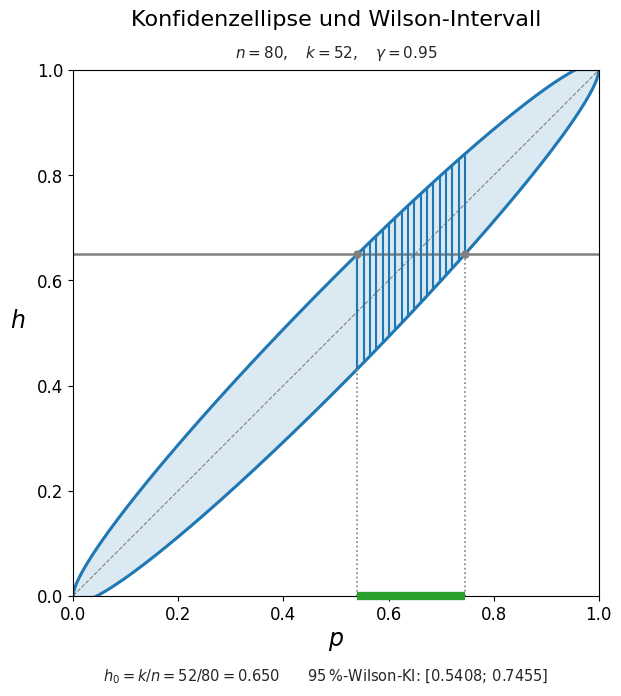

In [4]:
def number_token(value: float) -> str:
    text = f"{value:.6f}".rstrip("0").rstrip(".")
    return text.replace("-", "m").replace(".", "")


def figure_stem(cfg: Config) -> str:
    gamma = number_token(cfg.gamma)
    return (
        f"Wilson-Konfidenzellipse-n{cfg.n}-k{cfg.k}-"
        f"gamma{gamma}"
    )


def save_figure(
    fig: plt.Figure,
    cfg: Config,
) -> tuple[Path, ...]:
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    stem = figure_stem(cfg)
    saved_files: list[Path] = []

    for raw_format in cfg.save_formats:
        file_format = raw_format.lower().lstrip(".")
        output_path = output_dir / f"{stem}.{file_format}"
        save_options: dict[str, object] = {"bbox_inches": "tight"}
        if file_format == "png":
            save_options["dpi"] = cfg.png_dpi
        fig.savefig(output_path, **save_options)
        saved_files.append(output_path)

    return tuple(saved_files)


def print_results(
    cfg: Config,
    calculation: Calculation,
    saved_files: tuple[Path, ...],
) -> None:
    confidence = f"{100.0 * cfg.gamma:g}"
    print(
        f"h_0 = k/n = {cfg.k}/{cfg.n} = {calculation.h0:.4f}"
    )
    print(
        f"{confidence} %-Wilson-Konfidenzintervall: "
        f"[{calculation.p_left:.4f}; {calculation.p_right:.4f}]"
    )
    for output_path in saved_files:
        print(f"Gespeichert: {output_path}")


def run(cfg: Config) -> tuple[Calculation, tuple[Path, ...]]:
    calculation = calculate(cfg)
    fig, _ = create_figure(cfg, calculation)

    saved_files: tuple[Path, ...] = ()
    if cfg.save_figure:
        saved_files = save_figure(fig, cfg)

    if cfg.show_text_output:
        print_results(cfg, calculation, saved_files)

    if cfg.show_figure:
        plt.show()
    else:
        plt.close(fig)

    return calculation, saved_files


calculation, saved_files = run(cfg)